In [1]:
import numpy as np
import pandas as pd

# Load extracted EEG features
X = np.load("../data/features.npy")

# Load corresponding labels
y = np.load("../data/labels.npy")

print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)

print("\nClass Distribution:")
print("Normal Windows:", np.sum(y == 0))
print("Seizure Windows:", np.sum(y == 1))

Features Shape: (13181, 8)
Labels Shape: (13181,)

Class Distribution:
Normal Windows: 13080
Seizure Windows: 101


In [2]:

from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# stratify=y preserves the normal/seizure ratio
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:")
print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

print("\nTesting Set:")
print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)

print("\nTraining Class Distribution:")
print("Normal:", np.sum(y_train == 0))
print("Seizure:", np.sum(y_train == 1))

print("\nTesting Class Distribution:")
print("Normal:", np.sum(y_test == 0))
print("Seizure:", np.sum(y_test == 1))

Training Set:
X_train Shape: (10544, 8)
y_train Shape: (10544,)

Testing Set:
X_test Shape: (2637, 8)
y_test Shape: (2637,)

Training Class Distribution:
Normal: 10463
Seizure: 81

Testing Class Distribution:
Normal: 2617
Seizure: 20


In [3]:


from sklearn.ensemble import RandomForestClassifier

# Create baseline Random Forest model
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_baseline.fit(X_train, y_train)

print("Baseline Random Forest training completed!")

Baseline Random Forest training completed!


In [4]:

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# Make predictions on the test set
y_pred_baseline = rf_baseline.predict(X_test)

# Calculate confusion matrix
cm_baseline = confusion_matrix(
    y_test,
    y_pred_baseline
)

print("Baseline Confusion Matrix:")
print(cm_baseline)

print("\nBaseline Accuracy:")
print(f"{accuracy_score(y_test, y_pred_baseline) * 100:.2f}%")

print("\nBaseline Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_baseline,
        target_names=["Normal", "Seizure"],
        zero_division=0
    )
)

Baseline Confusion Matrix:
[[2617    0]
 [   6   14]]

Baseline Accuracy:
99.77%

Baseline Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2617
     Seizure       1.00      0.70      0.82        20

    accuracy                           1.00      2637
   macro avg       1.00      0.85      0.91      2637
weighted avg       1.00      1.00      1.00      2637



In [5]:
# ============================================
# CELL 5: Detailed Baseline Metrics
# ============================================

from sklearn.metrics import confusion_matrix

# Get TN, FP, FN, TP
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_baseline
).ravel()

# Calculate metrics
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = tp / (tp + fp)
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)

print("========== BASELINE MODEL METRICS ==========")

print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

print("\nSensitivity (Recall):", f"{sensitivity * 100:.2f}%")
print("Specificity:", f"{specificity * 100:.2f}%")
print("Precision:", f"{precision * 100:.2f}%")
print("F1-Score:", f"{f1_score:.2f}")

========== BASELINE MODEL METRICS ==========
True Negatives (TN): 2617
False Positives (FP): 0
False Negatives (FN): 6
True Positives (TP): 14

Sensitivity (Recall): 70.00%
Specificity: 100.00%
Precision: 100.00%
F1-Score: 0.82


In [6]:
# ============================================
# CELL 6: Threshold Optimization
# ============================================

import numpy as np
from sklearn.metrics import confusion_matrix

# Get probability of the Seizure class
y_prob = rf_baseline.predict_proba(X_test)[:, 1]

# Thresholds to evaluate
thresholds = [0.50, 0.40, 0.30, 0.20, 0.10]

print("========== THRESHOLD COMPARISON ==========\n")

for threshold in thresholds:

    # Convert probabilities into predictions
    y_pred_threshold = (y_prob >= threshold).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    # Calculate metrics
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    f1 = (
        2 * precision * sensitivity / (precision + sensitivity)
        if (precision + sensitivity) > 0
        else 0
    )

    accuracy = (tp + tn) / (tp + tn + fp + fn)

    print(f"Threshold: {threshold:.2f}")
    print(f"  Accuracy:    {accuracy * 100:.2f}%")
    print(f"  Sensitivity:  {sensitivity * 100:.2f}%")
    print(f"  Specificity:  {specificity * 100:.2f}%")
    print(f"  Precision:    {precision * 100:.2f}%")
    print(f"  F1-Score:     {f1:.2f}")
    print(f"  TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    print("-" * 40)

========== THRESHOLD COMPARISON ==========

Threshold: 0.50
  Accuracy:    99.77%
  Sensitivity:  70.00%
  Specificity:  100.00%
  Precision:    100.00%
  F1-Score:     0.82
  TN: 2617, FP: 0, FN: 6, TP: 14
----------------------------------------
Threshold: 0.40
  Accuracy:    99.81%
  Sensitivity:  80.00%
  Specificity:  99.96%
  Precision:    94.12%
  F1-Score:     0.86
  TN: 2616, FP: 1, FN: 4, TP: 16
----------------------------------------
Threshold: 0.30
  Accuracy:    99.81%
  Sensitivity:  80.00%
  Specificity:  99.96%
  Precision:    94.12%
  F1-Score:     0.86
  TN: 2616, FP: 1, FN: 4, TP: 16
----------------------------------------
Threshold: 0.20
  Accuracy:    99.73%
  Sensitivity:  85.00%
  Specificity:  99.85%
  Precision:    80.95%
  F1-Score:     0.83
  TN: 2613, FP: 4, FN: 3, TP: 17
----------------------------------------
Threshold: 0.10
  Accuracy:    99.32%
  Sensitivity:  95.00%
  Specificity:  99.35%
  Precision:    52.78%
  F1-Score:     0.68
  TN: 2600, FP: 17

In [7]:
# ============================================
# FINAL OPERATING THRESHOLD = 0.40
# ============================================

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Select final operating threshold
final_threshold = 0.40

# Generate final predictions
y_pred_final = (y_prob >= final_threshold).astype(int)

# Confusion matrix
cm_final = confusion_matrix(y_test, y_pred_final)

# Extract values
tn, fp, fn, tp = cm_final.ravel()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final)
sensitivity = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)

specificity = tn / (tn + fp)

print("==========================================")
print("FINAL RANDOM FOREST MODEL")
print("==========================================")

print("Operating Threshold:", final_threshold)

print("\nConfusion Matrix:")
print(cm_final)

print("\nFinal Metrics:")
print(f"Accuracy:    {accuracy * 100:.2f}%")
print(f"Sensitivity: {sensitivity * 100:.2f}%")
print(f"Specificity: {specificity * 100:.2f}%")
print(f"Precision:   {precision * 100:.2f}%")
print(f"F1-Score:    {f1:.2f}")

print("\nConfusion Matrix Values:")
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

FINAL RANDOM FOREST MODEL
Operating Threshold: 0.4

Confusion Matrix:
[[2616    1]
 [   4   16]]

Final Metrics:
Accuracy:    99.81%
Sensitivity: 80.00%
Specificity: 99.96%
Precision:   94.12%
F1-Score:    0.86

Confusion Matrix Values:
TN: 2616
FP: 1
FN: 4
TP: 16


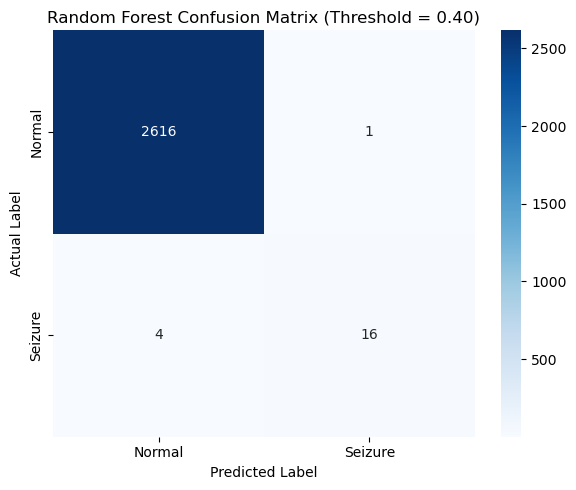

Final confusion matrix saved successfully!


In [8]:
# ============================================
# FINAL CONFUSION MATRIX VISUALIZATION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Seizure"],
    yticklabels=["Normal", "Seizure"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Confusion Matrix (Threshold = 0.40)")

plt.tight_layout()

# Save final confusion matrix
plt.savefig(
    "../images/random_forest_final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Final confusion matrix saved successfully!")

In [10]:
# Show all trained model-like variables currently available
print([name for name in globals() if "model" in name.lower() or "forest" in name.lower()])

['RandomForestClassifier', 'model_path']


In [11]:
# Show variables currently available in the notebook
print([name for name in globals() if not name.startswith("_")])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'np', 'pd', 'X', 'y', 'train_test_split', 'X_train', 'X_test', 'y_train', 'y_test', 'RandomForestClassifier', 'rf_baseline', 'confusion_matrix', 'classification_report', 'accuracy_score', 'y_pred_baseline', 'cm_baseline', 'tn', 'fp', 'fn', 'tp', 'sensitivity', 'specificity', 'precision', 'f1_score', 'y_prob', 'thresholds', 'threshold', 'y_pred_threshold', 'f1', 'accuracy', 'precision_score', 'recall_score', 'final_threshold', 'y_pred_final', 'cm_final', 'plt', 'sns', 'os', 'joblib', 'model_path']


In [12]:
# ============================================
# SAVE FINAL RANDOM FOREST MODEL
# ============================================

import os
import joblib

# Create models directory if it does not exist
os.makedirs("../models", exist_ok=True)

# Save the trained Random Forest model
model_path = "../models/random_forest_final.pkl"

joblib.dump(rf_baseline, model_path)

print("Final Random Forest model saved successfully!")
print("Model path:", model_path)

Final Random Forest model saved successfully!
Model path: ../models/random_forest_final.pkl


In [13]:
print(os.path.exists("../models/random_forest_final.pkl"))

True
